In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/')
from simulate_ALBF_calibration_eval import ALBFCalibrationAnalysis

In [2]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis"

# Choose which simulation directory to analyze 
dir_analyze="analysis_20250121_175021_PropNeg_0.1_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_30_LearnedConc_Inits_2_NoCellType_Random_89811"

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

['clustermap.png', 'losses.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'nmf_clustermap.png', 'random_init_63336_loss_curve.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'albf_vs_difference.png', 'cell_type_psi_df.csv', 'final_results.csv', 'random_init_73072_loss_curve.png', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [3]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

In [4]:
PSI_df[PSI_df["true_label"] == "negative"]

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
63,0,0.024623,0.024623,63,chr10_118152274_118156833_+,negative,35433,0.0,negative
64,1,0.950754,0.950754,64,chr10_118152274_118157194_+,negative,35433,0.0,negative
65,2,0.024623,0.024623,65,chr10_118156863_118157194_+,negative,35433,0.0,negative
108,0,0.483755,0.483755,108,chr10_127322890_127324344_+,negative,35899,0.0,negative
109,1,0.032489,0.032489,109,chr10_127322890_127325118_+,negative,35899,0.0,negative
...,...,...,...,...,...,...,...,...,...
15829,1,0.501782,0.501782,15829,chrX_7822390_7831171_+,negative,60492,0.0,negative
15830,2,0.249109,0.249109,15830,chrX_7824963_7831171_+,negative,60492,0.0,negative
15870,0,0.000714,0.000714,15870,chrX_95741971_95778894_+,negative,61005,0.0,negative
15871,1,0.998572,0.998572,15871,chrX_95741971_95898264_+,negative,61005,0.0,negative


In [5]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})
albf_scores.head()

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
0,0.369306,0.380687,0,1.176199,0.337561,positive,35178,1,0.011380,0
1,0.124882,0.341867,1,9.464796,0.675123,positive,35178,1,0.216985,1
2,0.468668,0.294295,2,1.936418,0.337561,positive,35178,1,0.174373,1
3,0.236037,0.483379,3,3.330473,0.289195,positive,37286,1,0.247341,1
4,0.326744,0.354849,4,1.337891,0.578390,positive,37286,1,0.028105,1


In [6]:
def analyze_null_albf(df):
    """
    Analyze ALBF distribution for negative junctions
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'ALBF' and 'true_label' columns
    
    Returns
    -------
    dict
        Dictionary containing null distribution parameters
    """
    # Get ALBF values for negative junctions
    null_albf = df[df['true_label'] == 'negative']['ALBF']
    
    # Fit normal distribution to null ALBFs
    mu, std = stats.norm.fit(null_albf)
    
    # Test for normality
    _, norm_pval = stats.normaltest(null_albf)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of null ALBF values
    sns.histplot(null_albf, bins=30, color='blue', alpha=0.5, label='Observed')
    
    # Plot fitted normal distribution
    x = np.linspace(null_albf.min(), null_albf.max(), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std) * len(null_albf) * (null_albf.max() - null_albf.min()) / 30,
             'r-', label='Fitted Normal')
    
    plt.title(f'Distribution of ALBF Values for Negative Junctions\nμ={mu:.2f}, σ={std:.2f}, p={norm_pval:.2e}')
    plt.xlabel('ALBF')
    plt.ylabel('Count')
    plt.legend()
    
    # Calculate percentiles for potential thresholds
    percentiles = [90, 95, 99]
    thresholds = np.percentile(null_albf, percentiles)
    
    return {
        'mu': mu,
        'std': std,
        'normality_pvalue': norm_pval,
        'thresholds': dict(zip(percentiles, thresholds))
    }

In [20]:
PSI_df[PSI_df["sample_label"] == "positive"]["difference"].min()

0.2500202

<Axes: >

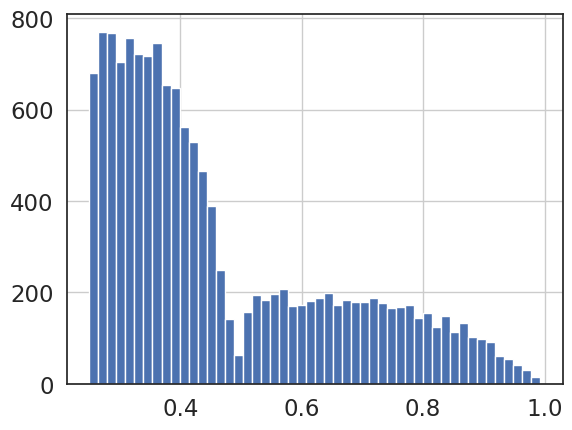

In [7]:
PSI_df[PSI_df["sample_label"] == "positive"]["difference"].hist(bins=50)

In [8]:
albf_scores.sort_values(by=["true_label", "ALBF"], ascending=[True, False], inplace=True)
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
14816,0.142032,0.063531,14816,40.451374,0.000000,negative,32397,0,0.078501,1
8087,0.062486,0.420986,8087,38.698223,0.000000,negative,8747,0,0.358500,1
12634,0.245642,0.079494,12634,31.994047,0.000000,negative,26416,0,0.166148,1
9242,0.204490,0.057854,9242,29.458395,0.000000,negative,9988,0,0.146635,1
7956,0.087120,0.104901,7956,29.183449,0.000000,negative,6635,0,0.017781,1
...,...,...,...,...,...,...,...,...,...,...
12280,0.517600,0.522533,12280,-0.314948,0.843745,positive,21302,1,0.004932,0
1246,0.486904,0.477419,1246,-0.331039,0.629214,positive,39302,1,0.009486,0
6361,0.506314,0.481975,6361,-0.336078,0.850165,positive,58813,1,0.024339,0
4963,0.480482,0.471000,4963,-0.347031,0.913780,positive,56360,1,0.009482,0


In [9]:
# get range of ALBF scores
albf_scores["ALBF"].min(), albf_scores["ALBF"].max()

(-0.35899746, 40.451374)

In [10]:
albf_scores[albf_scores["true_label"] == "negative"].sort_values(by="delta_est", ascending=False).head(100)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
13571,0.707143,0.229562,13571,7.659580,0.0,negative,23870,0,0.477581,1
2547,0.611670,0.143798,2547,16.881763,0.0,negative,46437,0,0.467873,1
13165,0.725445,0.260433,13165,11.088826,0.0,negative,26048,0,0.465013,1
220,0.819690,0.379376,220,13.348598,0.0,negative,37385,0,0.440314,1
12488,0.101432,0.517247,12488,9.279573,0.0,negative,27588,0,0.415814,1
...,...,...,...,...,...,...,...,...,...,...
8422,0.598646,0.353620,8422,2.666063,0.0,negative,6677,0,0.245026,1
2642,0.742465,0.497629,2642,3.716291,0.0,negative,46930,0,0.244836,1
10184,0.608192,0.363938,10184,2.180545,0.0,negative,13244,0,0.244254,1
10928,0.635313,0.391635,10928,1.502459,0.0,negative,16840,0,0.243678,1


In [11]:
PSI_df.iloc[178]

index                                        1
0                                     0.912687
1                                      0.15827
junction_id_index                          178
junction_id          chr10_20332261_20333391_+
sample_label                          positive
Cluster                                  35770
difference                            0.754417
true_label                            positive
Name: 178, dtype: object

In [12]:
albf_scores[albf_scores["Cluster"] == 35770]

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
179,0.151254,0.318631,179,7.194609,0.377208,positive,35770,1,0.167377,1
177,0.325907,0.272066,177,4.403825,0.377208,positive,35770,1,0.053841,1
178,0.678430,0.518316,178,1.327409,0.754417,positive,35770,1,0.160115,1


{'mu': 4.580345418201047,
 'std': 5.180439538737151,
 'normality_pvalue': 1.178507221590313e-132,
 'thresholds': {90: 11.931648200000005,
  95: 14.790120699999992,
  99: 22.645167839999992}}

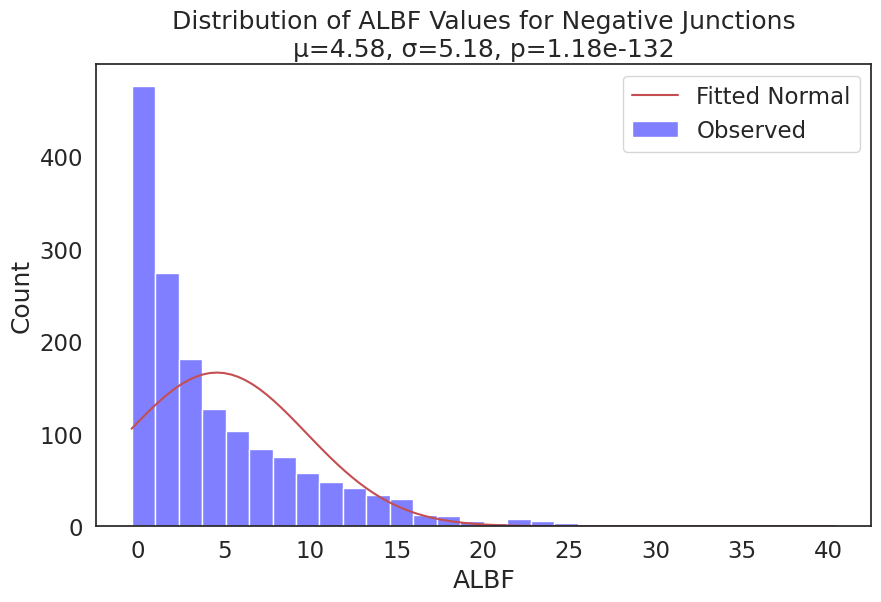

In [13]:
analyze_null_albf(albf_scores)

<Axes: xlabel='ALBF', ylabel='Count'>

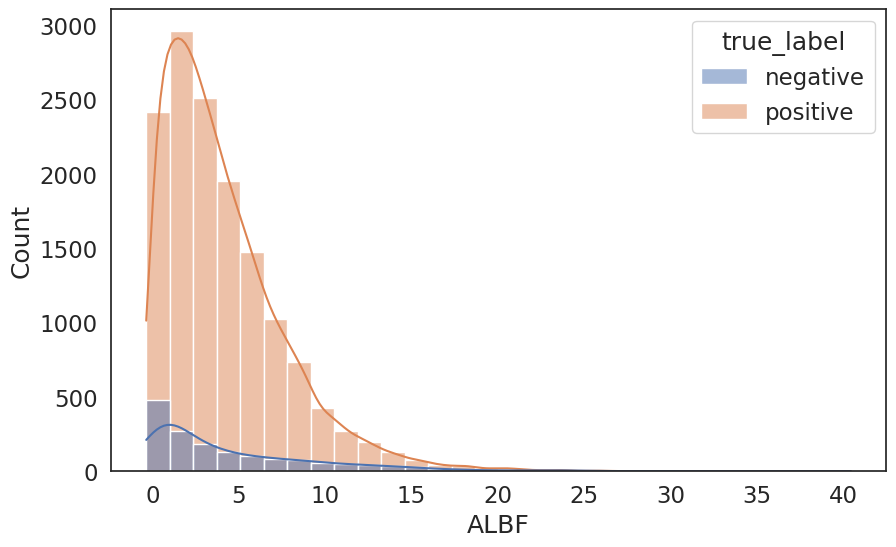

In [14]:
# Plot ALBF values distribtion for negative and positive junctions 
plt.figure(figsize=(10, 6))

# plot distplot 
sns.histplot(data=albf_scores, x='ALBF', hue='true_label', bins=30, kde=True, alpha=0.5)

<Axes: xlabel='difference', ylabel='ALBF'>

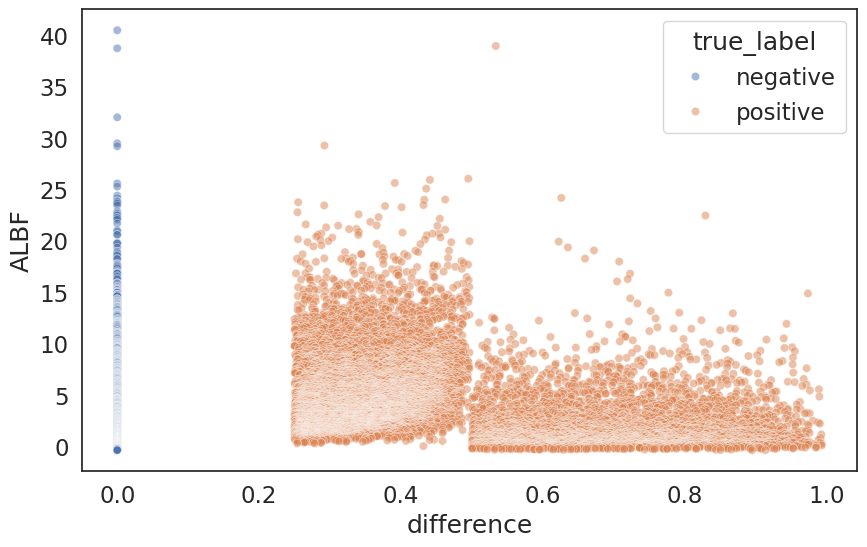

In [15]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='ALBF', alpha=0.5, hue='true_label')

<Axes: >

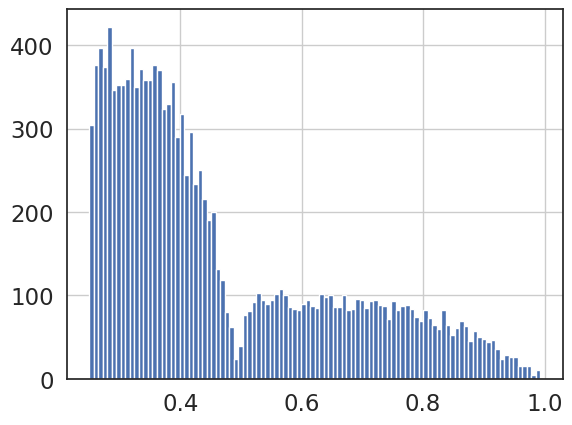

In [16]:
albf_scores[albf_scores["true_label"] == "positive"].difference.hist(bins=100)

<Axes: >

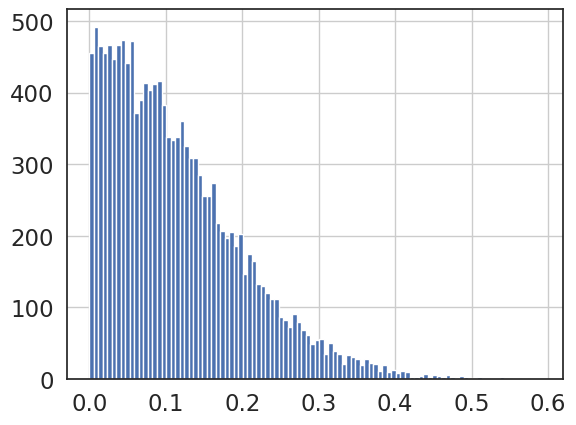

In [17]:
albf_scores[albf_scores["true_label"] == "positive"].delta_est.hist(bins=100)

In [18]:
PSI_df

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.494446,0.156884,0,chr10_100080130_100080856_+,positive,35178,0.337561,positive
1,1,0.011108,0.686231,1,chr10_100080130_100087346_+,positive,35178,0.675123,positive
2,2,0.494446,0.156884,2,chr10_100080940_100087346_+,positive,35178,0.337561,positive
3,0,0.162698,0.451893,3,chr10_100478022_100485050_-,positive,37286,0.289195,positive
4,1,0.674604,0.096214,4,chr10_100478022_100487161_-,positive,37286,0.578390,positive
...,...,...,...,...,...,...,...,...,...
15889,1,0.008971,0.996713,15889,chrY_898115_899427_+,positive,62094,0.987743,positive
15890,2,0.495515,0.001643,15890,chrY_898627_899427_+,positive,62094,0.493871,positive
15891,0,0.087670,0.431184,15891,chrY_900613_910447_+,positive,62095,0.343514,positive
15892,1,0.824659,0.137632,15892,chrY_910586_910656_+,positive,62095,0.687027,positive
